# Beyond tiles: free-form still-life images

This notebook walks through the algorithm developed in the *beyond-tiles*
feasibility spike (`experiments/beyond_tiles/`, full analysis in its
`REPORT.md`): mapping a greyscale image onto **one large Game-of-Life still
life** whose local live-cell density follows the image — with **no tile
vocabulary at all**.

The classic pipeline in this repository (Bosch & Olivieri style) fills the
canvas with pre-enumerated still-life *tiles*. Here instead a constraint
solver (Google OR-Tools **CP-SAT**) places every cell individually, subject
to:

1. **Stability (hard):** the whole pattern is a still life — every live cell
   has 2 or 3 live neighbours, no dead cell has exactly 3.
2. **Density (soft):** the canvas is divided into 8×8 windows; each window
   should contain a target number of live cells derived from the image's
   local grey value. The solver minimises the total deviation.

Closest prior art: Verrill, *Conway Still Life Drawing* (Bridges 2022) —
non-modular but binary masks only, fixed ~50% density, hours of annealing
for 40×40. The CP-SAT approach solves density-graded 200×200 portraits to
proven optimality in ~90 s.


## 0. Setup

Requires the `beyond` extra (`pip install ortools`).

In [1]:
import sys
from pathlib import Path

REPO = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
for p in (REPO / "src", REPO / "experiments"):
    sys.path.insert(0, str(p))

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

%matplotlib inline

## 1. From image to greyscale + subject mask

We reuse the tile pipeline's loader (`gol_mosaics.image_processing`): alpha
handling, optional background removal, sigmoid contrast — then pad to a
square and Lanczos-resize straight to the *cell grid*. One pixel = one
Game-of-Life cell. The alpha channel becomes the subject mask; background
cells will be forced dead.

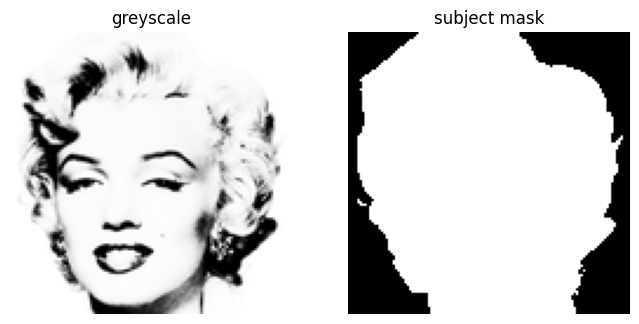

In [2]:
from beyond_tiles.targets import grey_and_mask_from_image

SIZE = 120  # cells per side — small enough to solve in ~a minute
grey, free = grey_and_mask_from_image(REPO / "input/images/marilyn.png", SIZE)

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(grey, cmap="gray"); axes[0].set_title("greyscale")
axes[1].imshow(free, cmap="gray"); axes[1].set_title("subject mask")
for ax in axes: ax.axis("off")

## 2. Tone mapping — the step that actually decides the picture

The spike's key debugging lesson: the solver was never the problem, the
*targets* were. This photo is high-key (subject median grey ≈ 234), so a
faithful absolute mapping `density = d_max · (1 − grey/255)` leaves the face
at density ≈ 0.03 — an unrecognisable scatter, even when the solver matches
it perfectly.

The fix mirrors what the tile pipeline does implicitly with its *relative*
density mapping: **histogram-equalize the grey values inside the subject
mask**. The subject's tones then span the full range and its median lands
near density 0.2 — the sweet spot for organic still-life texture.

Text(0.5, 1.0, 'subject histogram, equalized')

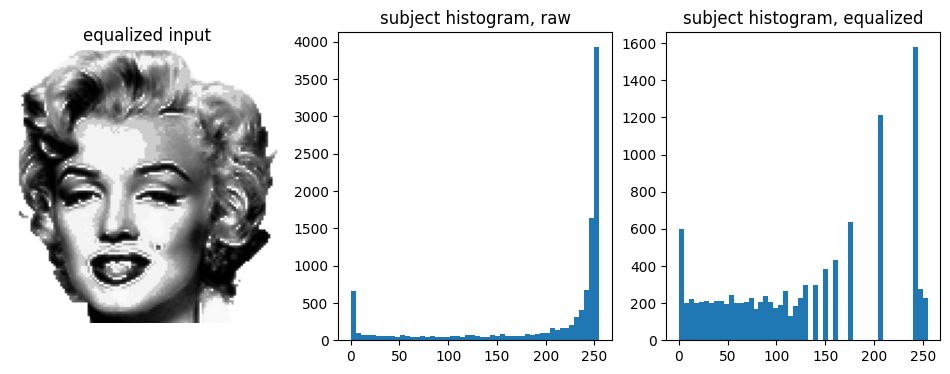

In [3]:
from beyond_tiles.targets import equalize_grey

eq = equalize_grey(grey, free)

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(eq, cmap="gray"); axes[0].set_title("equalized input"); axes[0].axis("off")
axes[1].hist(grey[free], bins=50); axes[1].set_title("subject histogram, raw")
axes[2].hist(eq[free], bins=50); axes[2].set_title("subject histogram, equalized")

## 3. Density targets per window

Per cell: `d = d_max · (1 − g/255)`, with `d_max = 0.45`. Elkies (1998)
proved still lifes cannot exceed density ½ asymptotically, so greyscale must
live in `[0, ~0.5]`; 0.45 leaves slack.

The canvas is covered by **disjoint 8×8 windows** and each window gets an
integer live-cell target (summed over its unmasked cells). The spike tested
50%-overlapping windows first — they only make the optimization 20–50×
harder; disjoint windows solve to *zero* total deviation with no visible
seams, because the stability constraints already couple neighbouring
windows.

192 windows, live-cell targets from 0 to 28


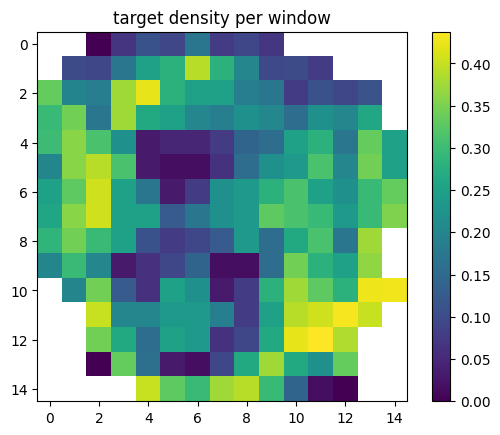

In [4]:
from beyond_tiles.targets import cell_targets, window_slices, window_targets

D_MAX, K = 0.45, 8
cell_t = cell_targets(eq, d_max=D_MAX)
windows = window_slices(cell_t.shape, k=K, stride=K)
targets, kept = window_targets(cell_t, free, windows)
print(f"{len(kept)} windows, live-cell targets from {targets.min()} to {targets.max()}")

field = np.full((SIZE // K + (SIZE % K > 0),) * 2, np.nan)
for t, (si, sj) in zip(targets, kept):
    field[si.start // K, sj.start // K] = t / free[si, sj].sum()
plt.imshow(field, cmap="viridis"); plt.title("target density per window"); plt.colorbar();

## 4. The constraint model

One boolean per cell on an (H+2)×(W+2) grid. The border ring is forced dead
**but still carries the no-birth constraint** — without it, a ring cell with
exactly 3 live interior neighbours would come alive in generation 1 and the
"still life" would ripple when opened in Golly.

For every cell, with `S` = sum of its in-grid Moore neighbours:

- **alive ⇒ S ∈ [2, 3]**  (survival)
- **dead ⇒ S ∈ {0,1,2} ∪ {4,…,8}**  (no birth)

both as half-reified linear constraints — CP-SAT handles these natively, no
auxiliary variables. Each kept window `w` gets `dev_w ≥ |Σ cells − t_w|` via
two inequalities, and the objective is `min Σ dev_w`. An all-dead grid is
trivially feasible, so the solver always holds an incumbent and improves it
("anytime" behaviour); with disjoint windows it typically reaches proven
optimality.

In [5]:
from beyond_tiles.still_image import SpikeConfig, solve_image

cfg = SpikeConfig(k=K, stride=K, d_max=D_MAX, time_limit_s=120.0, workers=10, seed=0)
result = solve_image(eq, free, cfg)
print(result.status, "| objective:", result.objective,
      f"| {result.wall_time_s:.1f}s | live cells: {int(result.pattern.sum())}")

OPTIMAL | objective: 1 | 23.7s | live cells: 2406


## 5. Verify: is it really a still life?

Two independent checks (plus, for the spike's headline patterns, a third via
`cellpylib` and a manual Golly session):

- `gol_mosaics.life.is_still_life` on the pattern padded by one dead ring —
  this check is *complete*: a birth two cells away from the pattern is
  impossible, so pad-1 covers every cell that could ever change.
- `gol_mosaics.sat_search.rule_violations` — an independent, vectorised
  toroidal implementation from the tile-census code path.

In [6]:
from beyond_tiles.still_image import verify_still_life

verify_still_life(result.pattern)

{'bounded': True, 'toroidal': True}

## 6. Look at it — and at how well density was matched


{'mad': 0.0087, 'p95': 0.0212, 'max': 0.3724, 'mad_darkest_quartile': 0.0165, 'pearson': 0.9592, 'n_windows': 192}


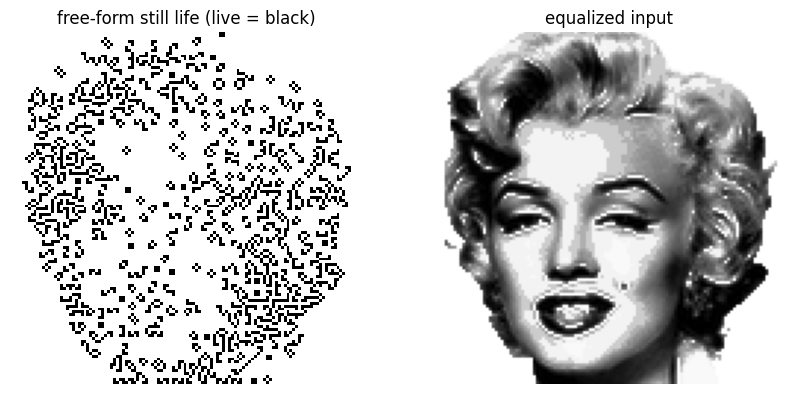

In [7]:
from beyond_tiles.metrics import deviation_stats

stats = deviation_stats(result.pattern, cell_t, free, kept)
print({k: round(v, 4) if isinstance(v, float) else v for k, v in stats.items()})

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(1 - result.pattern, cmap="gray", interpolation="nearest")
axes[0].set_title("free-form still life (live = black)")
axes[1].imshow(eq, cmap="gray"); axes[1].set_title("equalized input")
for ax in axes: ax.axis("off")

## 7. Export for Golly

`.cells` format via the repo's exporter. Open in Golly and press step —
nothing may move.

In [8]:
from gol_mosaics.export import GollyExporter

out = REPO / "output/golly/beyond_tiles_demo.cells"
out.parent.mkdir(parents=True, exist_ok=True)
GollyExporter.export_to_cells(result.pattern, str(out))
print("written:", out)

written: /Users/michielrollier/Developer/GitHub/game-of-life-mosaics/output/golly/beyond_tiles_demo.cells


## 8. Beyond this demo

- The experiment driver reproduces everything in the spike:
  `python experiments/beyond_tiles/run_experiment.py e2 --size 200 --stride 8 --tone eq`
- Measured scaling with disjoint windows (Apple M4, 10 workers): 100² in
  16 s, 200² in 87 s, both to proven optimality — see
  `experiments/beyond_tiles/REPORT.md` for the full E1–E5 analysis, the
  texture census proving the result is genuinely non-tiled (92% of 6×6
  blocks unique), and the comparison with tile mosaics and with Verrill's
  annealing approach.
- Seeds are the "new variation" knob: same image, same quality, different
  pattern.